In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# --- Step 1: Define the Economic Model ---
def simulate_demand(price, base_demand, price_sensitivity, competitor_price):
    """
    Calculates demand based on price, elasticity, and competitor positioning.
    """
    # Base linear demand curve: Q = a - bP
    demand = base_demand - (price_sensitivity * price)

    # Competitor Elasticity Penalty: If we charge more than competitors, demand drops faster
    if price > competitor_price:
        penalty = (price - competitor_price) * (price_sensitivity * 0.5)
        demand -= penalty

    # Demand cannot be negative
    return max(0, demand)

In [3]:
# --- Step 2: Deterministic Revenue Optimization ---
def optimize_pricing_deterministic(min_price=10, max_price=150, steps=100):
    """Finds the theoretical optimal price under perfect, static conditions."""
    print("⚙️ Running Deterministic Pricing Optimization...")

    # Static market assumptions
    base_demand = 5000
    price_sensitivity = 35
    competitor_price = 80

    prices = np.linspace(min_price, max_price, steps)
    results = []

    for p in prices:
        q = simulate_demand(p, base_demand, price_sensitivity, competitor_price)
        revenue = p * q
        results.append({'Price': p, 'Demand': q, 'Revenue': revenue})

    df = pd.DataFrame(results)

    # Find the row with maximum revenue
    optimal_scenario = df.loc[df['Revenue'].idxmax()]

    print("\n📊 --- STATIC MARKET RESULTS ---")
    print(f"Optimal Price: ₹{optimal_scenario['Price']:.2f}")
    print(f"Projected Demand: {int(optimal_scenario['Demand'])} units")
    print(f"Maximized Revenue: ₹{optimal_scenario['Revenue']:,.2f}")

    return df, optimal_scenario

In [4]:
# --- Step 3: 🔥 Monte Carlo Simulation (Handling Uncertainty) ---
def optimize_pricing_monte_carlo(iterations=1000, min_price=10, max_price=150):
    """Simulates thousands of volatile market scenarios to find the safest optimal price."""
    print(f"\n🎲 Running Monte Carlo Simulation ({iterations} iterations)...")

    prices = np.linspace(min_price, max_price, 50)
    optimal_prices_history = []

    for _ in range(iterations):
        # Introduce random noise to our market assumptions
        base_demand = np.random.normal(5000, 500) # Mean 5000, SD 500
        price_sensitivity = np.random.normal(35, 5) # Mean 35, SD 5
        competitor_price = np.random.normal(80, 10) # Mean 80, SD 10

        best_rev = 0
        best_price = 0

        for p in prices:
            q = simulate_demand(p, base_demand, price_sensitivity, competitor_price)
            rev = p * q
            if rev > best_rev:
                best_rev = rev
                best_price = p

        optimal_prices_history.append(best_price)

    # Calculate the median optimal price across all volatile scenarios
    robust_optimal_price = np.median(optimal_prices_history)
    confidence_interval = np.percentile(optimal_prices_history, [5, 95])

    print("\n🌪️ --- VOLATILE MARKET RESULTS (MONTE CARLO) ---")
    print(f"Robust Optimal Price: ₹{robust_optimal_price:.2f}")
    print(f"90% Confidence Interval: ₹{confidence_interval[0]:.2f} - ₹{confidence_interval[1]:.2f}")
    print("----------------------------------------------\n")

    return optimal_prices_history

In [5]:
# --- Step 4: Visualization Dashboard ---
def plot_pricing_dashboard(df_static, monte_carlo_results):
    plt.style.use('dark_background')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Static Revenue Curve
    ax1.plot(df_static['Price'], df_static['Revenue'], color='#00ffcc', linewidth=2.5)
    optimal_p = df_static.loc[df_static['Revenue'].idxmax(), 'Price']
    optimal_r = df_static['Revenue'].max()

    ax1.axvline(x=optimal_p, color='red', linestyle='--', alpha=0.7)
    ax1.scatter(optimal_p, optimal_r, color='red', s=100, zorder=5)
    ax1.set_title("Theoretical Revenue Optimization Curve", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Price Point (₹)")
    ax1.set_ylabel("Projected Revenue (₹)")
    ax1.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

    # Plot 2: Monte Carlo Distribution
    ax2.hist(monte_carlo_results, bins=30, color='#ff00cc', alpha=0.7, edgecolor='white')
    ax2.axvline(x=np.median(monte_carlo_results), color='yellow', linestyle='dashed', linewidth=2)
    ax2.set_title("Monte Carlo: Optimal Price Distribution", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Optimal Price (₹)")
    ax2.set_ylabel("Frequency (Scenarios)")
    ax2.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

    plt.tight_layout()
    plt.show()

⚙️ Running Deterministic Pricing Optimization...

📊 --- STATIC MARKET RESULTS ---
Optimal Price: ₹70.81
Projected Demand: 2521 units
Maximized Revenue: ₹178,557.95

🎲 Running Monte Carlo Simulation (1000 iterations)...

🌪️ --- VOLATILE MARKET RESULTS (MONTE CARLO) ---
Robust Optimal Price: ₹70.00
90% Confidence Interval: ₹55.57 - ₹87.14
----------------------------------------------



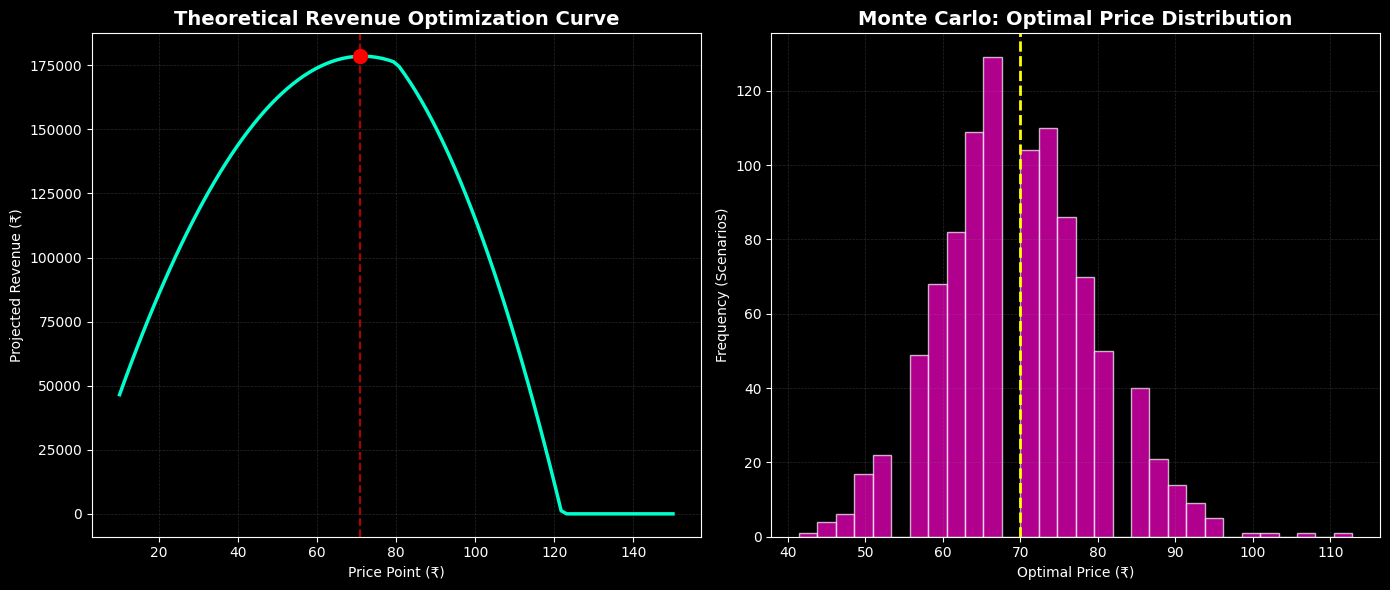

In [6]:
if __name__ == "__main__":
    static_df, static_best = optimize_pricing_deterministic()
    mc_results = optimize_pricing_monte_carlo()
    plot_pricing_dashboard(static_df, mc_results)